# LLM-as-Judge vs Human Annotations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("../data/outputs/llm_as_judge_3_8_annotated.csv")
df.drop(columns = ["Unnamed: 0"], inplace = True)
df.head()

,topic,synthetic_code_mixed,level,llm_output,llm_coherence,llm_naturalness,llm_readability,annotator_1_coherence,annotator_1_naturalness,annotator_1_readabilty,annotator_1_comments,annotator_2_coherence,annotator_2_naturalness,annotator_2_readabilty,annotator_2_comments,annotator_3_coherence,annotator_3_naturalness,annotator_3_readabilty,annotator_3_comments
0,business,"""Bugün şirkette çok önemli bir meeting var, o ...",2.0,Concise and refined evaluation analysis:\nThe ...,3,3,3,3,2,3,"""toplanti"" is much more likely to be used inst...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gaming,"""Bu akşam multiplayer modunda oyun oynayalım, ...",2.0,Concise and refined evaluation analysis:\n\nTh...,3,3,3,3,3,3,"Since most games are in English, this is a lik...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,music,"""Bugün harika bir concert dinleyeceğiz, müzik ...",2.0,Concise and refined evaluation analysis:\nThe ...,3,3,3,3,1,3,"""konser"" already available as a Turkish word. ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tv,"""Bu akşam yeni bir dizi release ediyor, gerçek...",NaN,Concise and refined evaluation analysis:\nThe ...,3,3,3,2,1,3,"Never heard ""dizi release"", also ""ediliyor"", n...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sports,"""Geçen hafta sonu bir futbol match vardı ve ge...",NaN,Concise and refined evaluation analysis:\nThe ...,3,3,3,3,1,3,"""mac"" already in Turkish",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


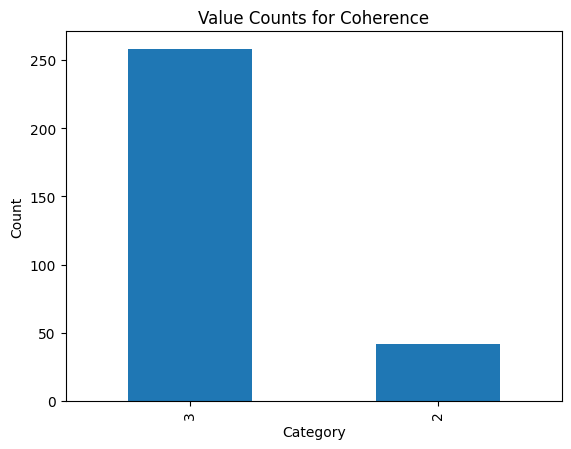

In [15]:
sorted_by_value_coherence = df['annotator_1_coherence'].value_counts().sort_index(ascending=False)
sorted_by_value_coherence.plot(kind='bar')

plt.title('Value Counts for Coherence')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

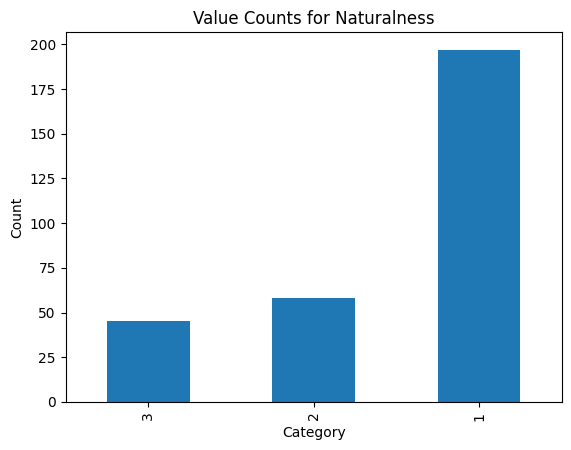

In [16]:
sorted_by_value_naturalness = df['annotator_1_naturalness'].value_counts().sort_index(ascending=False)
sorted_by_value_naturalness.plot(kind='bar')
plt.title('Value Counts for Naturalness')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

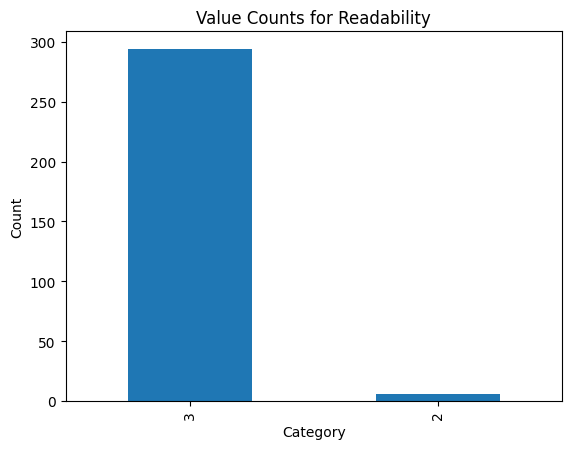

In [4]:
sorted_by_value_readability = df['llm_readability'].value_counts().sort_index(ascending=False)
sorted_by_value_readability.plot(kind='bar')
plt.title('Value Counts for Readability')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

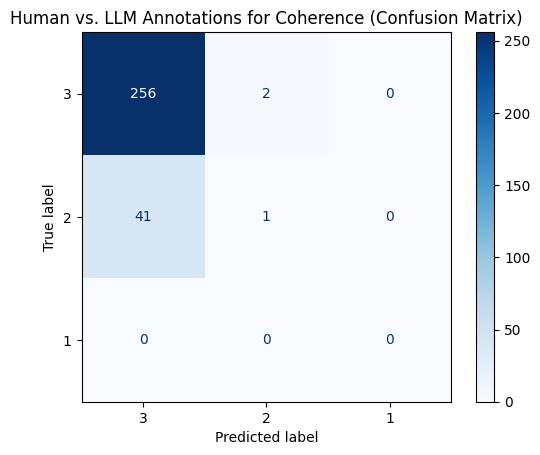

In [28]:
cm = confusion_matrix(df["annotator_1_coherence"], df['llm_coherence'], labels=[3, 2, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["3", "2", "1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Human vs. LLM Annotations for Coherence (Confusion Matrix)")
plt.show()

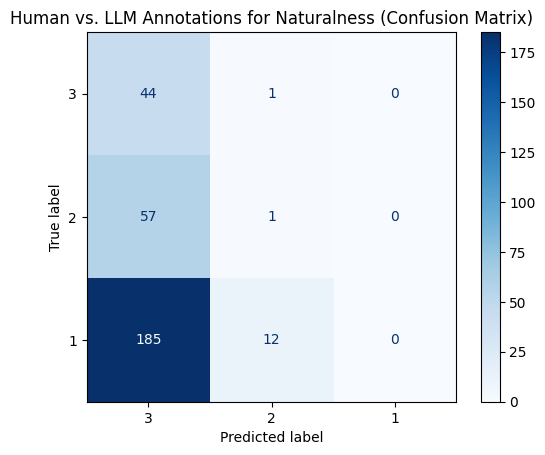

In [29]:
cm = confusion_matrix(df["annotator_1_naturalness"], df['llm_naturalness'], labels=[3, 2, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["3", "2", "1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Human vs. LLM Annotations for Naturalness (Confusion Matrix)")
plt.show()

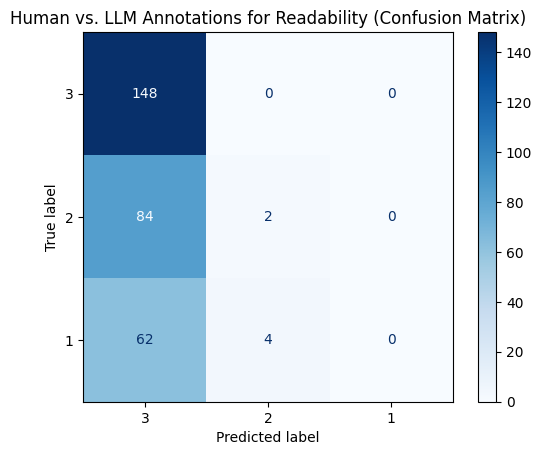

In [31]:
cm = confusion_matrix(df["annotator_1_readabilty"], df['llm_readability'], labels=[3, 2, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["3", "2", "1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Human vs. LLM Annotations for Readability (Confusion Matrix)")
plt.show()

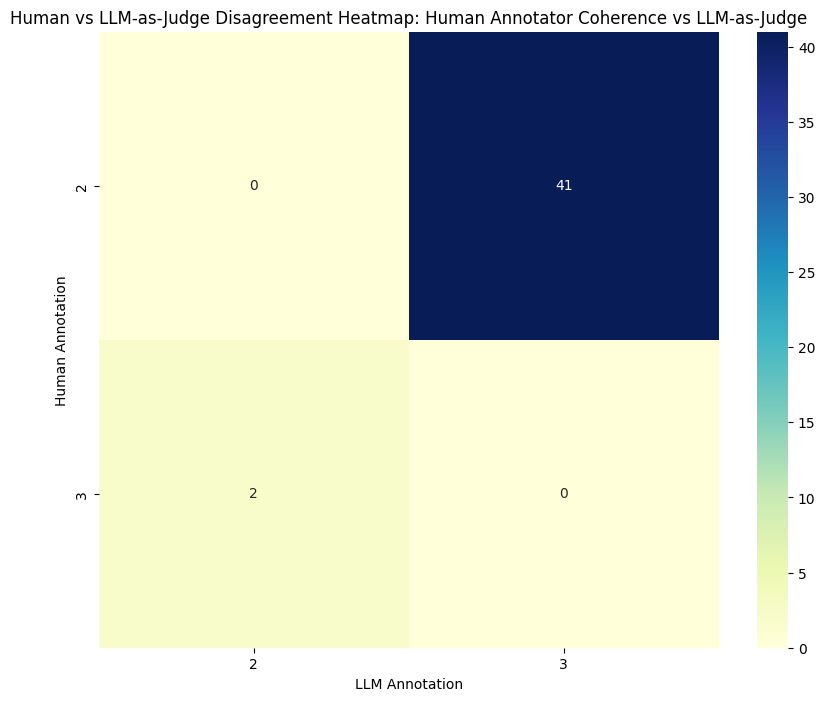

In [33]:
mismatched_rows_coherence = df[df['llm_coherence'] != df["annotator_1_coherence"]]
cm = pd.crosstab(mismatched_rows_coherence['annotator_1_coherence'], mismatched_rows_coherence['llm_coherence'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Human vs LLM-as-Judge Disagreement Heatmap: Human Annotator Coherence vs LLM-as-Judge')
plt.ylabel('Human Annotation')
plt.xlabel('LLM Annotation')
plt.show()

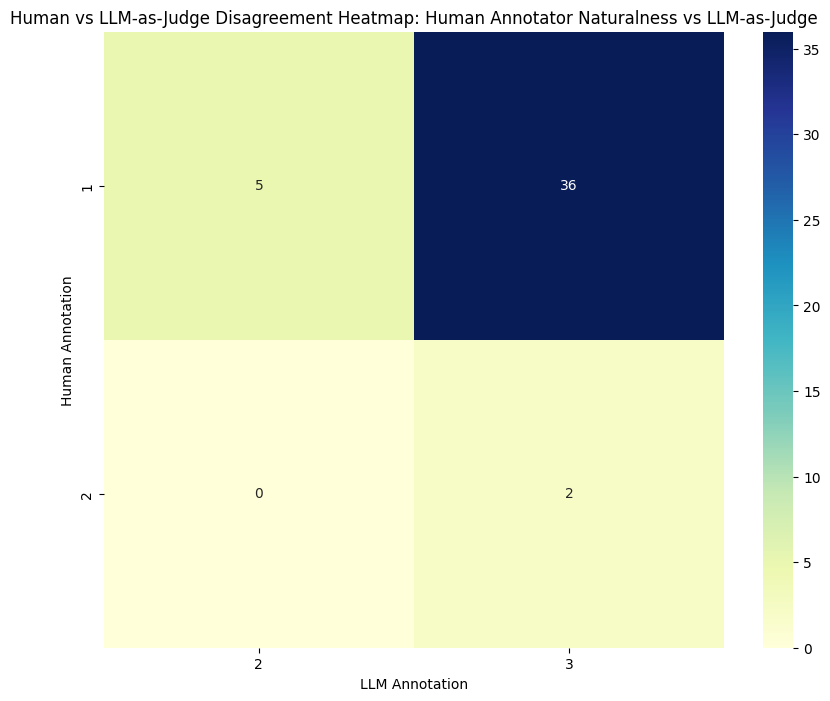

In [35]:
mismatched_rows_naturalness = df[df['llm_naturalness'] != df["annotator_1_naturalness"]]
cm = pd.crosstab(mismatched_rows_coherence['annotator_1_naturalness'], mismatched_rows_coherence['llm_naturalness'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Human vs LLM-as-Judge Disagreement Heatmap: Human Annotator Naturalness vs LLM-as-Judge')
plt.ylabel('Human Annotation')
plt.xlabel('LLM Annotation')
plt.show()

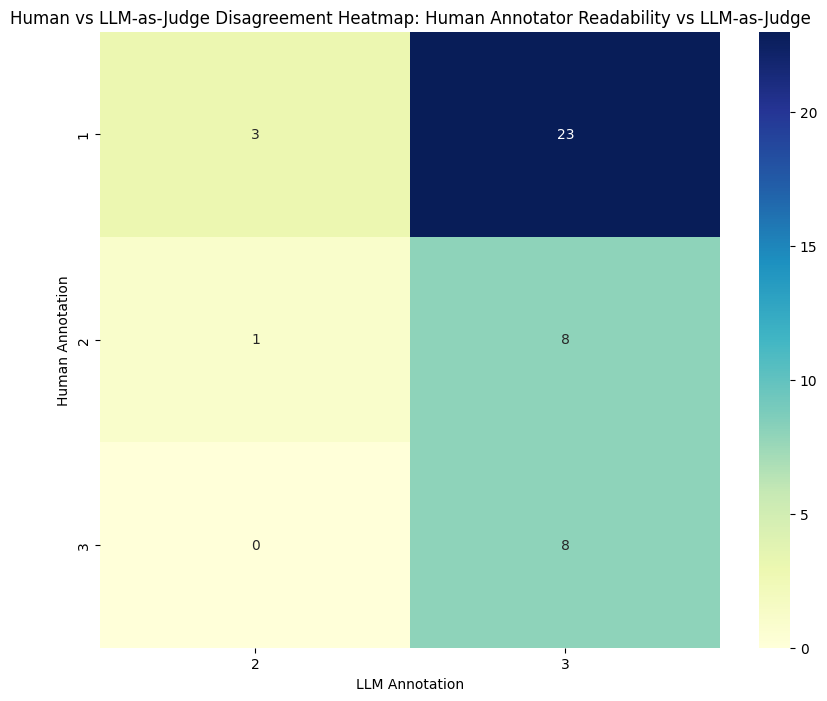

In [36]:
mismatched_rows_readability = df[df['llm_readability'] != df["annotator_1_readabilty"]]
cm = pd.crosstab(mismatched_rows_coherence['annotator_1_readabilty'], mismatched_rows_coherence['llm_readability'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Human vs LLM-as-Judge Disagreement Heatmap: Human Annotator Readability vs LLM-as-Judge')
plt.ylabel('Human Annotation')
plt.xlabel('LLM Annotation')
plt.show()

In [40]:
macro_f1 = f1_score(df["annotator_1_coherence"], df["llm_coherence"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.4835



In [41]:
macro_f1 = f1_score(df["annotator_1_naturalness"], df["llm_naturalness"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.0979



In [43]:
macro_f1 = f1_score(df["annotator_1_readabilty"], df["llm_readability"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.2377



In [37]:
print("Classification Report:")
print(classification_report(df["annotator_1_coherence"], df["llm_coherence"]))

Classification Report:
              precision    recall  f1-score   support

           2       0.33      0.02      0.04        42
           3       0.86      0.99      0.92       258

    accuracy                           0.86       300
   macro avg       0.60      0.51      0.48       300
weighted avg       0.79      0.86      0.80       300



In [38]:
print("Classification Report:")
print(classification_report(df["annotator_1_naturalness"], df["llm_naturalness"]))

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       197
           2       0.07      0.02      0.03        58
           3       0.15      0.98      0.27        45

    accuracy                           0.15       300
   macro avg       0.08      0.33      0.10       300
weighted avg       0.04      0.15      0.05       300



/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [39]:
print("Classification Report:")
print(classification_report(df["annotator_1_readabilty"], df["llm_readability"]))

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        66
           2       0.33      0.02      0.04        86
           3       0.50      1.00      0.67       148

    accuracy                           0.50       300
   macro avg       0.28      0.34      0.24       300
weighted avg       0.34      0.50      0.34       300



/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera